# Transient heat equation on a U-shaped domain — AlphaPINN spectral PINN

**PDE:**  $\partial_t u - \kappa\,\Delta u = 0$  (heat / diffusion)

**Domain:**  $[0,2]\times[0,2]$ minus a notch $(x\in(0.6,1.4),\; y>0.8)$,  time $t\in[0,T]$

**Initial condition:**  $u(x,y,0) = 0$

**Boundary conditions:**
- $u = 1$ on the **left-arm top** ($y=2,\; x\in[0,0.6]$) — hot, held for all $t$
- $u = 0$ everywhere else on the boundary — cold, held for all $t$

**Method:**  **AlphaPINN — global spectral PINN without Method of Lines.**

Since the Laplace eigenvectors $\Phi$ are global spatial modes, the full
space-time solution can be written as:

$$u(x,t) = \Phi\,\alpha(t), \quad \alpha(t) = \text{FNN}(t) \in \mathbb{R}^K$$

The FNN takes only $t$ as input and outputs the spectral expansion coefficients.
Time derivatives follow by autodiff; no state, no rollout, no BPTT.

Physics is enforced through the Galerkin weak-form residual:

$$\int_\Omega \phi\,\partial_t u\,d\Omega + \kappa\int_\Omega \nabla u\cdot\nabla\phi\,d\Omega = 0 \quad \forall\,\phi\in V_h, \; t\in[0,T]$$

The IC $u(\cdot,0)=0$ is added as a Dirichlet BC on the $t=0$ face of the domain.


## 1. Imports & environment

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ.setdefault("PINNS_BACKEND", "jax")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from collections import Counter

import pygmsh

import jax
import jax.numpy as jnp

from pinns import DomainMesh, AlphaPINNNetwork
from pinns.backends.jax import Trainer
from pinns.problem_weak import ProblemWeak


## 2. Build the U-shaped triangulated mesh

Mesh: 311 nodes, 532 triangles


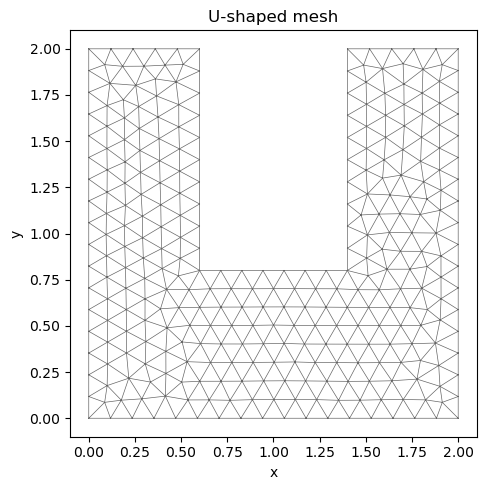

In [2]:
X_MAX    = 2.0
Y_MAX    = 2.0
NOTCH_X  = (0.6, 1.4)
NOTCH_Y  = 0.8
MESH_SIZE = 0.12

T_MAX    = 1.0    # total simulation time
KAPPA    = 0.05   # diffusion coefficient

def in_u_shape(pts: np.ndarray) -> np.ndarray:
    x, y   = pts[:, 0], pts[:, 1]
    in_box = (x >= 0) & (x <= X_MAX) & (y >= 0) & (y <= Y_MAX)
    in_cut = (x > NOTCH_X[0]) & (x < NOTCH_X[1]) & (y > NOTCH_Y)
    return in_box & ~in_cut

u_polygon = [
    [0.0,        0.0     ],
    [X_MAX,      0.0     ],
    [X_MAX,      Y_MAX   ],
    [NOTCH_X[1], Y_MAX   ],
    [NOTCH_X[1], NOTCH_Y ],
    [NOTCH_X[0], NOTCH_Y ],
    [NOTCH_X[0], Y_MAX   ],
    [0.0,        Y_MAX   ],
]

with pygmsh.geo.Geometry() as geom:
    geom.add_polygon(u_polygon, mesh_size=MESH_SIZE)
    mesh = geom.generate_mesh(dim=2, verbose=False)

verts = mesh.points[:, :2].copy()
faces = mesh.cells_dict["triangle"].astype(np.int64)

used        = np.unique(faces)
remap       = np.full(len(verts), -1, dtype=np.int64)
remap[used] = np.arange(len(used))
verts       = verts[used]
faces       = remap[faces]

print(f"Mesh: {len(verts)} nodes, {len(faces)} triangles")

fig, ax = plt.subplots(figsize=(5, 5))
tri_vis = mtri.Triangulation(verts[:, 0], verts[:, 1], faces)
ax.triplot(tri_vis, "k-", lw=0.5, alpha=0.6)
ax.set_aspect("equal"); ax.set_title("U-shaped mesh")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()


## 3. Identify boundary nodes

Hot nodes  (u=1): 6
Cold nodes (u=0): 82
Interior nodes  : 223


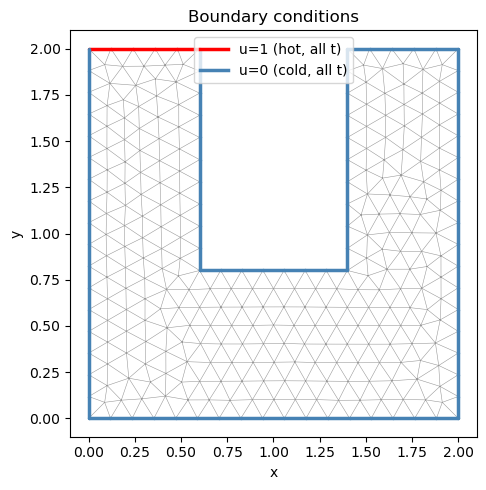

In [3]:
edge_count = Counter()
for tri_idx in faces:
    for i in range(3):
        e = tuple(sorted([tri_idx[i], tri_idx[(i + 1) % 3]]))
        edge_count[e] += 1

boundary_verts_idx = set()
for (v0, v1), cnt in edge_count.items():
    if cnt == 1:
        boundary_verts_idx.update([v0, v1])
boundary_verts_idx = np.array(sorted(boundary_verts_idx))

is_boundary = np.zeros(len(verts), dtype=bool)
is_boundary[boundary_verts_idx] = True

tol    = MESH_SIZE / 2
is_hot = (verts[:, 1] >= Y_MAX - tol) & (verts[:, 0] <= NOTCH_X[0] + tol) & is_boundary

print(f"Hot nodes  (u=1): {is_hot.sum()}")
print(f"Cold nodes (u=0): {(is_boundary & ~is_hot).sum()}")
print(f"Interior nodes  : {(~is_boundary).sum()}")

from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(5, 5))
ax.triplot(tri_vis, "k-", lw=0.4, alpha=0.4)
for (v0, v1), cnt in edge_count.items():
    if cnt == 1:
        color = "red" if (is_hot[v0] and is_hot[v1]) else "steelblue"
        ax.plot([verts[v0, 0], verts[v1, 0]], [verts[v0, 1], verts[v1, 1]],
                color=color, lw=2.5, solid_capstyle="round")
ax.legend(handles=[
    Line2D([0],[0], color="red",       lw=2.5, label="u=1 (hot, all t)"),
    Line2D([0],[0], color="steelblue", lw=2.5, label="u=0 (cold, all t)"),
])
ax.set_aspect("equal"); ax.set_title("Boundary conditions")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()


## 4. Finite-difference transient reference solution

Solve $\partial_t u = \kappa\,\Delta u$ with implicit Euler on a $100\times100$ regular grid.
The resulting space-time interpolant `fd_solution(x)` accepts columns $(x, y, t)$ and is
used by the trainer to log the relative L2 error at every checkpoint.

In [4]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.interpolate import LinearNDInterpolator

N_FD = 100
xs_fd   = np.linspace(0, X_MAX, N_FD + 1)
ys_fd   = np.linspace(0, Y_MAX, N_FD + 1)
h_fd    = xs_fd[1] - xs_fd[0]
XX_fd, YY_fd = np.meshgrid(xs_fd, ys_fd, indexing='ij')

pts_flat = np.column_stack([XX_fd.ravel(), YY_fd.ravel()])
active   = in_u_shape(pts_flat).reshape(N_FD + 1, N_FD + 1)

node_id = np.full((N_FD + 1, N_FD + 1), -1, dtype=np.int64)
node_id[active] = np.arange(active.sum())
n_dof   = active.sum()
ii, jj  = np.where(active)

def _is_bnd(i, j):
    if not active[i, j]: return False
    for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
        ni, nj = i+di, j+dj
        if ni < 0 or ni > N_FD or nj < 0 or nj > N_FD or not active[ni, nj]:
            return True
    return False

bnd   = np.array([_is_bnd(i, j) for i, j in zip(ii, jj)])
hot   = bnd & (YY_fd[ii, jj] >= Y_MAX - h_fd/2) & (XX_fd[ii, jj] <= NOTCH_X[0] + h_fd/2)
bc_val = np.where(hot, 1.0, 0.0)

# Stiffness matrix (κ × 5-point Laplacian)
rows, cols, vals = [], [], []
for idx, (i, j) in enumerate(zip(ii, jj)):
    k = node_id[i, j]
    if bnd[idx]:
        rows.append(k); cols.append(k); vals.append(-1.0)
    else:
        rows.append(k); cols.append(k); vals.append(-KAPPA * 4.0 / h_fd**2)
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
            nk = node_id[i+di, j+dj]
            rows.append(k); cols.append(nk); vals.append(KAPPA * 1.0 / h_fd**2)

A_mat = sp.csr_matrix((vals, (rows, cols)), shape=(n_dof, n_dof))

N_TIME = 50
dt_fd  = T_MAX / N_TIME
ts_fd  = np.linspace(0, T_MAX, N_TIME + 1)

M_diag = np.ones(n_dof); M_diag[bnd] = 0.0
M_mat  = sp.diags(M_diag / dt_fd, format='csr')
LHS    = M_mat - A_mat
b_bc   = np.zeros(n_dof); b_bc[bnd] = bc_val[bnd]

u_cur = np.zeros(n_dof)
LHS_lu = spla.splu(LHS.tocsc())
U_all  = np.zeros((N_TIME + 1, n_dof))
U_all[0] = u_cur

for n_step in range(N_TIME):
    rhs = (M_mat @ u_cur) + b_bc
    rhs[bnd] = bc_val[bnd]
    u_cur = LHS_lu.solve(rhs)
    U_all[n_step + 1] = u_cur

print(f"FD transient (κ={KAPPA}): {n_dof} DOFs × {N_TIME} steps")
print(f"u range at t=T: [{U_all[-1].min():.4f}, {U_all[-1].max():.4f}]")

# Space-time interpolant
xy_active = pts_flat[active.ravel()]
Xst, Yst, Tst, Ust = [], [], [], []
for n_step, t in enumerate(ts_fd):
    Xst.append(xy_active[:, 0]); Yst.append(xy_active[:, 1])
    Tst.append(np.full(n_dof, t)); Ust.append(U_all[n_step])

fd_interp_st = LinearNDInterpolator(
    np.column_stack([np.concatenate(Xst), np.concatenate(Yst), np.concatenate(Tst)]),
    np.concatenate(Ust), fill_value=np.nan
)

def fd_solution(x: np.ndarray) -> np.ndarray:
    """Space-time FD reference: (n_pts, 3) cols (x,y,t) → (n_pts, 1)."""
    vals   = fd_interp_st(x[:, :3]).reshape(-1, 1)
    in_dom = in_u_shape(x[:, :2]).reshape(-1, 1)
    vals[~in_dom] = np.nan
    return vals

print("Space-time interpolant ready.")


FD transient (κ=0.05): 7861 DOFs × 50 steps
u range at t=T: [-0.0000, 1.0000]


Space-time interpolant ready.


## 5. Spatial domain & AlphaPINN spectral network

`DomainMesh` carries a `t_interval` so the collocation points include time.

`AlphaPINNNetwork` is built with `use_time=True`: the FNN maps
$t \mapsto \alpha(t) \in \mathbb{R}^K$, and the field is decoded as
$u(x,t) = \Phi\,\alpha(t)$ — no state, no rollout, autodiff supplies $\partial_t u$.


In [6]:
T_MAX    = 1.0    # total simulation time
KAPPA    = 0.05   # diffusion coefficient

# ── Space-time domain ────────────────────────────────────────────────────
domain = DomainMesh((verts, faces), t_interval=[0.0, T_MAX])

# Spatial boundary conditions (held for all t)
domain.add_dirichlet(
    select=lambda v: is_hot,
    value=1.0,
    component=0,
    name="hot_top",
    t_mode="all",
)
domain.add_dirichlet(
    select=lambda v: is_boundary & ~is_hot,
    value=0.0,
    component=0,
    name="cold_walls",
    t_mode="all",
)

# Initial condition u(x,y,0)=0 — soft BC at t=t_min.
# Only interior (non-boundary) nodes: boundary nodes are already constrained
# by their spatial BCs.  Hot boundary nodes start at u=1 by construction;
# enforcing IC=0 there would create a contradiction.
domain.add_dirichlet(
    select=lambda v: ~is_boundary,
    value=0.0,
    component=0,
    name="ic_zero",
    t_mode="t_min",
)
print(domain)

# ── AlphaPINN spectral network ───────────────────────────────────────────
# use_time=True: FNN maps t → α(t) ∈ ℝᴷ, then u(x,t)=Φ α(t)
# No state, no rollout, ∂_t u obtained by autodiff through FNN(t)
net = AlphaPINNNetwork(
    domain,
    n_eigenvectors   = 32,     # K — enough for smooth diffusion
    hidden_dim       = 128,
    n_layers         = 4,
    activation       = 'tanh',
    n_outputs        = 1,
    hard_constraints = True,   # enforce spatial BCs by static condensation
    use_time         = True,   # t is the only FNN input
)
print(net)


DomainMesh(2D × t∈[0.0, 1.0], n_nodes=311, n_conditions=3)
AlphaPINNNetwork: computing 32 Laplace eigenvectors for mesh with 311 nodes … done.
AlphaPINNNetwork(n_nodes=311, K=32, hidden_dim=128, n_layers=4, n_outputs=1, hard_constraints=True, use_state=False, use_time=True)


## 6. PDE problem — continuous transient weak form

$$\int_\Omega \phi\,\partial_t u\,d\Omega + \kappa\int_\Omega \nabla u\cdot\nabla\phi\,d\Omega = 0$$

Because $u(x,t)=\Phi\,\alpha(t)$ and $\Phi$ is mesh-based (not a function of $t$),
the trainer's `derivative(y, x, comp, (2,))` call differentiates through the FNN
with respect to $t$ — no finite differences, no implicit Euler.

No `n_time_steps`, no curriculum, no BPTT.


In [7]:
def volume_fn(x, y, params, phi, grad_phi, derivative=None):
    """Continuous transient weak form: ∫ φ ∂_t u dΩ + κ ∫ ∇u·∇φ dΩ"""
    kappa = params["fixed"]["kappa"]

    du_dt = derivative(y, x, 0, (2,))              # ∂u/∂t  (autodiff through FNN)
    du_dx = derivative(y, x, 0, (0,))              # ∂u/∂x
    du_dy = derivative(y, x, 0, (1,))              # ∂u/∂y
    grad_u = jnp.stack([du_dx, du_dy], axis=-1)   # (n_pts, 2)  — spatial only

    return phi * du_dt + kappa * jnp.sum(grad_u * grad_phi, axis=-1)

problem = ProblemWeak(
    domain      = domain,
    volume_fn   = volume_fn,
    params      = {"kappa": float(KAPPA)},
    input_names = ["x", "y", "t"],
    output_names = ["u"],
    cubature_order = 4,
    # solution=None — per-epoch error logging skipped; evaluated in post-processing
    # (sample_interior returns only spatial pts, not space-time, so the 3D
    #  interpolant cannot be used here)
)

problem.show_problem()


<IPython.core.display.Math object>

'\\min_{\\theta}\\;\\mathcal{L}(\\theta)=\\frac{w_{pde}}{N_e}\\sum_e\\!\\left(\\int_{K_e}\\nabla u_h\\cdot\\nabla\\phi\\,dK\\right)^2 + \\frac{w_{hot\\_top}}{N_{hot\\_top}}\\left\\|\\mathcal{B}_{hot\\_top}\\right\\|_2^2 + \\frac{w_{cold\\_walls}}{N_{cold\\_walls}}\\left\\|\\mathcal{B}_{cold\\_walls}\\right\\|_2^2 + \\frac{w_{ic\\_zero}}{N_{ic\\_zero}}\\left\\|\\mathcal{B}_{ic\\_zero}\\right\\|_2^2 \\\\[4pt] \\begin{array}{l} K_e:\\text{ mesh element (triangle)} \\\\ N_e:\\text{ number of elements} \\\\ w_{pde}:\\text{ PDE weight} \\\\ \\mathcal{B}_{hot\\_top}:\\text{ Dirichlet residual on }hot\\_top \\\\ N_{hot\\_top}:\\text{ BC nodes for }hot\\_top \\\\ w_{hot\\_top}:\\text{ weight for }hot\\_top \\\\ \\mathcal{B}_{cold\\_walls}:\\text{ Dirichlet residual on }cold\\_walls \\\\ N_{cold\\_walls}:\\text{ BC nodes for }cold\\_walls \\\\ w_{cold\\_walls}:\\text{ weight for }cold\\_walls \\\\ \\mathcal{B}_{ic\\_zero}:\\text{ Dirichlet residual on }ic\\_zero \\\\ N_{ic\\_zero}:\\text{ BC nod

## 7. Training

Standard PINN training — no curriculum, no BPTT.  The full space-time loss:

$$\mathcal{L}(\theta) = \|\mathcal{R}(u_\theta)\|^2 + \lambda_\text{BC}\|\text{BCs}\|^2 + \lambda_\text{IC}\|u_\theta(\cdot,0)\|^2$$

is minimised in one shot.


Starting training for 10000 epochs (JIT-compiled)...


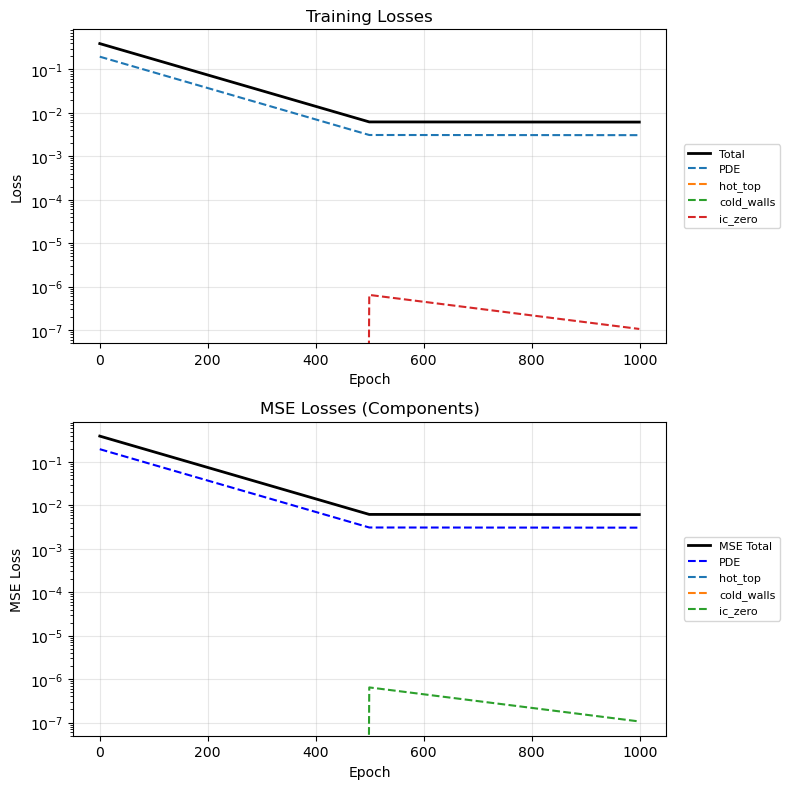

Epoch 0/10000 | Loss: 3.93e-01 | MSE Loss: 3.93e-01 | PDE: 1.96e-01 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00, ic_zero: 0.00e+00] | Time: 0.0s
Epoch 500/10000 | Loss: 6.18e-03 | MSE Loss: 6.18e-03 | PDE: 3.09e-03 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00, ic_zero: 6.44e-07] | Time: 75.7s
Epoch 1000/10000 | Loss: 6.13e-03 | MSE Loss: 6.13e-03 | PDE: 3.06e-03 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00, ic_zero: 1.06e-07] | Time: 155.8s


In [ ]:
trainer = Trainer(problem, net)
trainer.compile(
    learning_rate = 1e-3,
    epochs        = 10_000,
    print_each    = 500,
    show_plots    = True,
)
trainer.train()